## Project Overview

College Readiness & Completion Analysis | Classes 2016–2025
Institution: Cristo Rey Jesuit High School
Analyst: [Nathan Rayle] | Academic Data Manager & M.S. Data Science Candidate
Data: Full population, 908 students, Classes of 2016–2025
Last Updated: 5/19/2026

This notebook evaluates whether the school's college readiness designation — GPA ≥ 3.0 and at least one ACT benchmark met — predicts college graduation within six years. Classes of 2016–2019 are the primary analysis cohort. Class of 2020 is included with caveats. Class of 2021 is exclud (no testing data). Classes of 2022–2025 receive projected graduation likelihoods based on the model trained on prior cohorts. Methods include permutation testing, bootstrapped confidence intervals, and logistic regression, interpreted under population-level data assumptions.

See README for full study design, variable definitions, and cohort logic.



In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
 
# ── Load ──────────────────────────────────────────────────────────────────────
# The source file is a tab-delimited .txt. We keep only the columns we need
# and rename them to clean working names.
 
df = pd.read_csv(
    "College Readiness Data.txt",          # ← replace with your actual filename
    sep="\t",
    usecols=[2, 3, 5, 6, 7, 9, 10],   # columns C, D, F, G, H, J, K (0-indexed)
    names=[
        "Student_Number",          # A — skipped
        "Name",                    # B — skipped
        "Class_Of",                # C ✓
        "GPA",                     # D ✓
        "Test",                    # E — skipped
        "Met_GPA",                 # F ✓
        "Met_Benchmark",           # G ✓
        "College_Ready",           # H ✓
        "Match_Field",             # I — skipped
        "College_Status",          # J ✓
        "Met_Both_Benchmarks"      # K ✓
    ],
    header=0                       # row 0 is the original header, drop it
)
df = df.dropna(subset=["Class_Of"]).reset_index(drop=True)
# shape check
print(df.shape)
print(df.dtypes)
print(df.head())

(908, 7)
Class_Of                 int64
GPA                    float64
Met_GPA                    str
Met_Benchmark              str
College_Ready              str
College_Status             str
Met_Both_Benchmarks        str
dtype: object
   Class_Of   GPA Met_GPA Met_Benchmark College_Ready       College_Status  \
0      2016  3.27     Yes           Yes           Yes   Graduated (2-Year)   
1      2016  3.32     Yes            No            No   No Longer Enrolled   
2      2016  3.32     Yes            No            No   No Longer Enrolled   
3      2016  3.52     Yes           Yes           Yes   No Longer Enrolled   
4      2016  3.57     Yes           Yes           Yes  Credential Received   

  Met_Both_Benchmarks  
0                  No  
1                  No  
2                  No  
3                 Yes  
4                  No  


# Step One: Data Cleaning

Data was collected from the School SIS, National Clearing House, The College Board and ACT. Most of the data was cleaned prior to loading into the notebook. 

## College Readiness Definition
A student is designated College Ready if they meet both of the following:

1. GPA ≥ 3.0

2. At least one standardized test benchmark met.
Students in the Classes of 2016–2020 took the ACT. The ACT defines college readiness benchmarks as the minimum score associated with a 50% likelihood
of earning at least a C in a corresponding first-year college course. Two subject areas qualify:

Reading & English — first-year humanities and writing coursework
Math — first-year mathematics coursework

A student needs to clear at least one of these two subject benchmarks to satisfy the readiness criteria. Needing only one is a deliberately low bar — a student could be flagged as College Ready on the strength of a single subject area alone.

In [2]:
# Data Cleaning


df["Class_Of"] = df["Class_Of"].astype(str).str.replace(".0", "", regex=False)

counts = df["Class_Of"].value_counts().sort_index()
 
SEP = "=" * 45

print(f"\n{SEP}")
print("  NULL COUNTS PER COLUMN")
print(SEP)
print(df.isnull().sum().to_string())
 
# ── Data Types ────────────────────────────────────────────────────────────────
print(f"\n{SEP}")
print("  DATA TYPES")
print(SEP)
print(df.dtypes.to_string())
 
# ── Classes Present ───────────────────────────────────────────────────────────
print(f"\n{SEP}")
print("  CLASSES PRESENT")
print(SEP)
print("  " + ", ".join(sorted([x for x in df["Class_Of"].unique() if x != "nan"])))
 
# ── Sample ────────────────────────────────────────────────────────────────────
print(f"\n{SEP}")
print("  SAMPLE (first 5 rows)")
print(SEP)
print(df.head().to_string(index=False))
 

 


  NULL COUNTS PER COLUMN
Class_Of               0
GPA                    0
Met_GPA                0
Met_Benchmark          0
College_Ready          0
College_Status         0
Met_Both_Benchmarks    0

  DATA TYPES
Class_Of                   str
GPA                    float64
Met_GPA                    str
Met_Benchmark              str
College_Ready              str
College_Status             str
Met_Both_Benchmarks        str

  CLASSES PRESENT
  2016, 2017, 2018, 2019, 2020, 2022, 2023, 2024, 2025

  SAMPLE (first 5 rows)
Class_Of  GPA Met_GPA Met_Benchmark College_Ready      College_Status Met_Both_Benchmarks
    2016 3.27     Yes           Yes           Yes  Graduated (2-Year)                  No
    2016 3.32     Yes            No            No  No Longer Enrolled                  No
    2016 3.32     Yes            No            No  No Longer Enrolled                  No
    2016 3.52     Yes           Yes           Yes  No Longer Enrolled                 Yes
    2016 3.57     Y

# Step 2: Descriptive Statistics:

Before running any resampling methods we want to see the raw picture clearly. We start with graduation rates broken down by College Ready designation across the full analysis cohort (Classes of 2016–2020), then look at how those rates vary by graduating class. This gives us a baseline to test against and surfaces any cohort-level trends worth noting before we move into permutation testing and bootstrapping.

### Null Hypothesis:

H₀: College Ready designation has no relationship with college graduation within six years. Any observed difference in graduation rates betweenCollege Ready and non-College Ready students is due to chance.

### Alternative Hypothesis:

H₁: Students designated College Ready graduate from college within six years at a meaningfully higher rate than those who are not. (one-tailed)

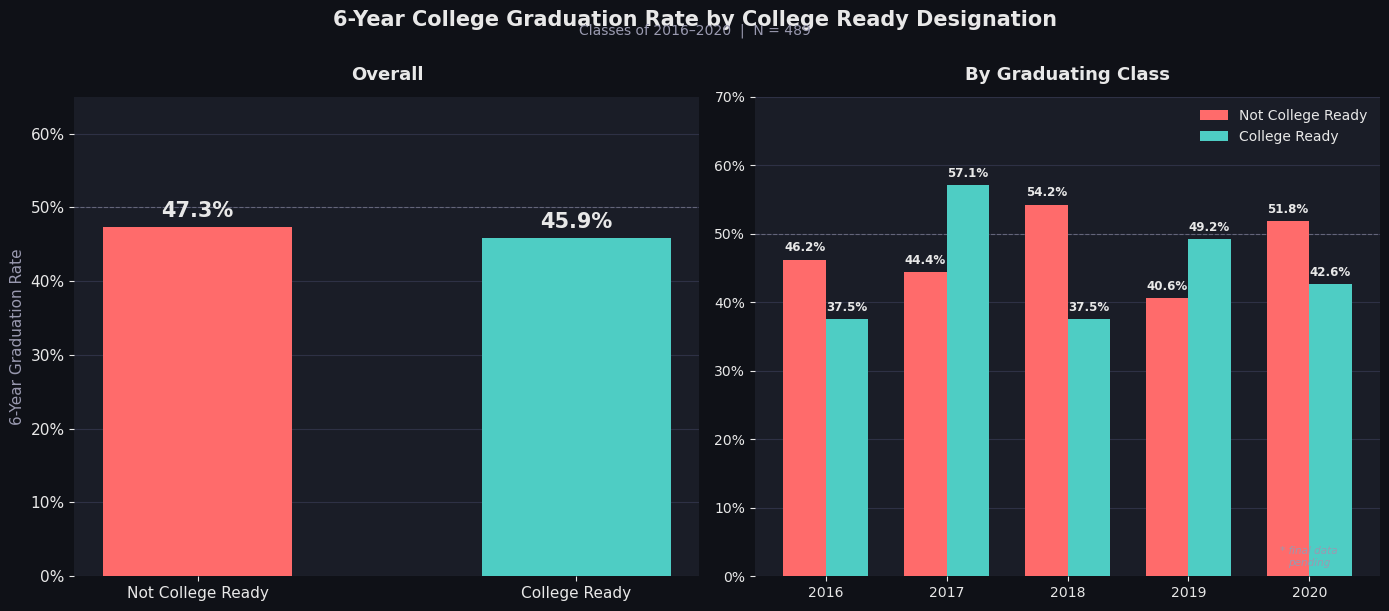


  STUDENTS PER GRADUATING CLASS
  Class Of        N    % Met 1 Benchmark   % Met Both
  ------------ ----   ------------------   ----------
  2016           71                45.1%        15.5%
  2017           85                57.6%        20.0%
  2018           80                40.0%        13.8%
  2019          129                50.4%        22.5%
  2020          124                54.8%        25.0%
  2022          104                40.4%        23.1%
  2023          115                33.0%        13.0%
  2024          100                44.0%        20.0%
  2025          100                46.0%        23.0%
               ----
  Total         908

  GRADUATION RATE BY COLLEGE READY STATUS
  Classes of 2016–2020  |  N = 489
  College Ready        N   Graduated     Rate
  ---------------- -----   ---------   ------
  No                 243         115    47.3%
  Yes                246         113    45.9%

  GRADUATION RATE BY CLASS & COLLEGE READY STATUS
  Class    Ready    

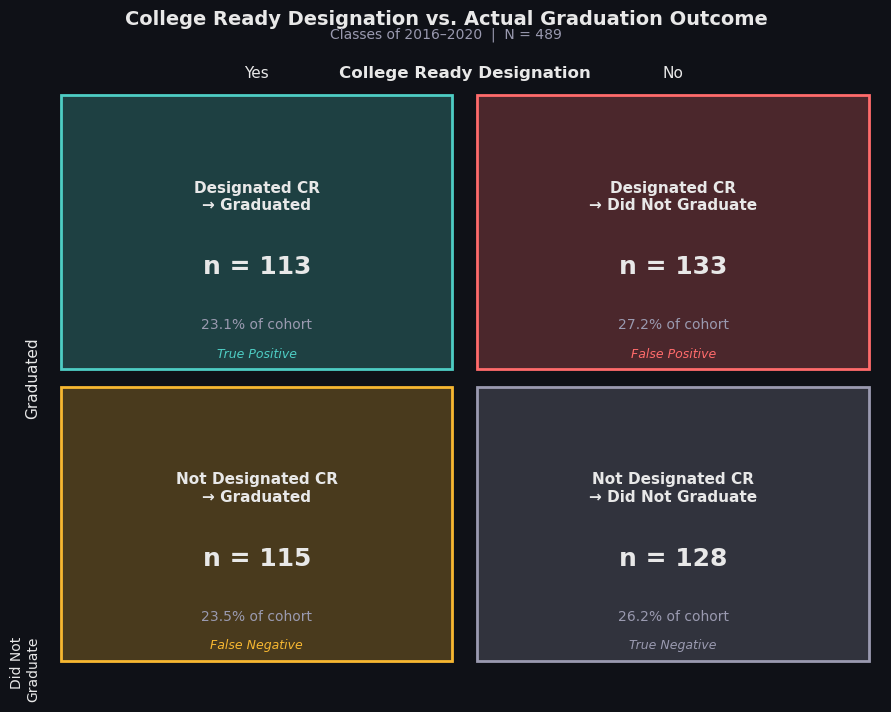

In [3]:
SEP = "=" * 60
 
# ── Analysis Cohort ───────────────────────────────────────────────────────────
analysis_years = ["2016", "2017", "2018", "2019", "2020"]
cohort = df[df["Class_Of"].isin(analysis_years)].copy()
 
# ── Derive Graduation Outcome ─────────────────────────────────────────────────
graduation_statuses = {
    "Graduated (4-Year)",
    "Graduated (2-Year)",
    "Graduated (4-Year), Continuing",
    "Graduated (2-Year), Continuing",
    "Credential Received"
}
cohort["Graduated"] = cohort["College_Status"].str.strip().isin(graduation_statuses)
 
# ── Aggregations ──────────────────────────────────────────────────────────────
overall  = cohort.groupby("College_Ready")["Graduated"].agg(["sum", "count"])
overall["rate"] = overall["sum"] / overall["count"] * 100
overall.columns = ["Graduated", "Total", "Grad Rate %"]
 
by_class = cohort.groupby(["Class_Of", "College_Ready"])["Graduated"].agg(["sum", "count"])
by_class["rate"] = by_class["sum"] / by_class["count"] * 100
 
counts   = df["Class_Of"].value_counts().sort_index()
ready_ct = df[df["College_Ready"] == "Yes"].groupby("Class_Of").size()
both_ct  = df[df["Met_Both_Benchmarks"] == "Yes"].groupby("Class_Of").size()
 
# ── Plot ──────────────────────────────────────────────────────────────────────
READY_COLOR    = "#4ecdc4"
NOTREADY_COLOR = "#ff6b6b"
BG             = "#0f1117"
PANEL_BG       = "#1a1d27"
TEXT           = "#e8e8e8"
SUBTEXT        = "#9a9ab0"
 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(BG)
 
ax1 = axes[0]
ax1.set_facecolor(PANEL_BG)
labels = ["Not College Ready", "College Ready"]
values = [47.3, 45.9]
colors = [NOTREADY_COLOR, READY_COLOR]
bars   = ax1.bar(labels, values, color=colors, width=0.5, zorder=3, edgecolor="none")
for bar, val in zip(bars, values):
    ax1.text(bar.get_x() + bar.get_width() / 2, val + 0.8,
             f"{val}%", ha="center", va="bottom",
             fontsize=15, fontweight="bold", color=TEXT)
ax1.axhline(50, color=SUBTEXT, linewidth=0.8, linestyle="--", zorder=2, alpha=0.5)
ax1.set_ylim(0, 65)
ax1.set_ylabel("6-Year Graduation Rate", color=SUBTEXT, fontsize=11)
ax1.set_title("Overall", color=TEXT, fontsize=13, fontweight="bold", pad=12)
ax1.tick_params(colors=TEXT, labelsize=11)
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
for spine in ax1.spines.values():
    spine.set_visible(False)
ax1.yaxis.grid(True, color="#2e3145", linewidth=0.8, zorder=0)
ax1.set_axisbelow(True)
 
ax2 = axes[1]
ax2.set_facecolor(PANEL_BG)
years     = ["2016", "2017", "2018", "2019", "2020"]
not_ready = [46.2, 44.4, 54.2, 40.6, 51.8]
ready     = [37.5, 57.1, 37.5, 49.2, 42.6]
x         = range(len(years))
width     = 0.35
b1 = ax2.bar([i - width/2 for i in x], not_ready, width=width,
             color=NOTREADY_COLOR, label="Not College Ready", zorder=3, edgecolor="none")
b2 = ax2.bar([i + width/2 for i in x], ready, width=width,
             color=READY_COLOR, label="College Ready", zorder=3, edgecolor="none")
for bar, val in zip(b1, not_ready):
    ax2.text(bar.get_x() + bar.get_width() / 2, val + 0.8,
             f"{val}%", ha="center", va="bottom", fontsize=8.5, color=TEXT, fontweight="bold")
for bar, val in zip(b2, ready):
    ax2.text(bar.get_x() + bar.get_width() / 2, val + 0.8,
             f"{val}%", ha="center", va="bottom", fontsize=8.5, color=TEXT, fontweight="bold")
ax2.text(4, 1.5, "* final data\npending", ha="center",
         fontsize=7.5, color=SUBTEXT, style="italic")
ax2.axhline(50, color=SUBTEXT, linewidth=0.8, linestyle="--", zorder=2, alpha=0.5)
ax2.set_ylim(0, 70)
ax2.set_xticks(list(x))
ax2.set_xticklabels(years, color=TEXT, fontsize=11)
ax2.set_title("By Graduating Class", color=TEXT, fontsize=13, fontweight="bold", pad=12)
ax2.tick_params(colors=TEXT, labelsize=10)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
for spine in ax2.spines.values():
    spine.set_visible(False)
ax2.yaxis.grid(True, color="#2e3145", linewidth=0.8, zorder=0)
ax2.set_axisbelow(True)
ax2.legend(facecolor=PANEL_BG, edgecolor="none", labelcolor=TEXT, fontsize=10, loc="upper right")
fig.suptitle("6-Year College Graduation Rate by College Ready Designation",
             color=TEXT, fontsize=15, fontweight="bold", y=1.01)
fig.text(0.5, 0.97, "Classes of 2016–2020  |  N = 489",
         ha="center", color=SUBTEXT, fontsize=10)
plt.tight_layout()
plt.savefig("graduation_rate_by_readiness.png", dpi=180, bbox_inches="tight", facecolor=BG)
plt.show()
 
# ── Print: Class Counts ───────────────────────────────────────────────────────
print(f"\n{SEP}")
print("  STUDENTS PER GRADUATING CLASS")
print(SEP)
print(f"  {'Class Of':<12} {'N':>4}   {'% Met 1 Benchmark':>18}   {'% Met Both':>10}")
print(f"  {'-'*12} {'-'*4}   {'-'*18}   {'-'*10}")
for year, n in counts.items():
    pct_one  = (ready_ct.get(year, 0) / n) * 100
    pct_both = (both_ct.get(year, 0) / n) * 100
    print(f"  {year:<12} {n:>4}   {pct_one:>17.1f}%   {pct_both:>9.1f}%")
print(f"  {'':12} {'----':>4}")
print(f"  {'Total':<12} {counts.sum():>4}")
print(SEP)
 
# ── Print: Overall Graduation Rate ────────────────────────────────────────────
print(f"\n{SEP}")
print("  GRADUATION RATE BY COLLEGE READY STATUS")
print(f"  Classes of 2016–2020  |  N = {len(cohort)}")
print(SEP)
print(f"  {'College Ready':<16} {'N':>5}   {'Graduated':>9}   {'Rate':>6}")
print(f"  {'-'*16} {'-'*5}   {'-'*9}   {'-'*6}")
for status, row in overall.iterrows():
    print(f"  {status:<16} {int(row['Total']):>5}   {int(row['Graduated']):>9}   {row['Grad Rate %']:>5.1f}%")
print(SEP)
 
# ── Print: By Class ───────────────────────────────────────────────────────────
print(f"\n{SEP}")
print("  GRADUATION RATE BY CLASS & COLLEGE READY STATUS")
print(SEP)
print(f"  {'Class':<8} {'Ready':<8} {'N':>5}   {'Graduated':>9}   {'Rate':>6}")
print(f"  {'-'*8} {'-'*8} {'-'*5}   {'-'*9}   {'-'*6}")
for (year, status), row in by_class.iterrows():
    print(f"  {year:<8} {status:<8} {int(row['count']):>5}   {int(row['sum']):>9}   {row['rate']:>5.1f}%")
print(SEP + "\n")
 
# ── Four-Group Benchmark Breakdown ────────────────────────────────────────────
def benchmark_group(row):
    one  = row["Met_Benchmark"] == "Yes"
    both = row["Met_Both_Benchmarks"] == "Yes"
    if both:
        return "Met Both"
    elif one:
        return "Met One Only"
    else:
        return "Met Neither"
 
cohort["Benchmark_Group"] = cohort.apply(benchmark_group, axis=1)
 
grp_order = ["Met Neither", "Met One Only", "Met Both"]
grp_stats = cohort.groupby("Benchmark_Group")["Graduated"].agg(["sum", "count"])
grp_stats["rate"] = grp_stats["sum"] / grp_stats["count"] * 100
 
print(f"\n{SEP}")
print("  GRADUATION RATE BY BENCHMARK GROUP")
print(SEP)
print(f"  {'Group':<16} {'N':>5}   {'Graduated':>9}   {'Rate':>6}")
print(f"  {'-'*16} {'-'*5}   {'-'*9}   {'-'*6}")
for grp in grp_order:
    row = grp_stats.loc[grp]
    print(f"  {grp:<16} {int(row['count']):>5}   {int(row['sum']):>9}   {row['rate']:>5.1f}%")
print(SEP)
 
# ── Graduation Rate by Met Both — By Class ────────────────────────────────────
both_class = cohort.groupby(["Class_Of", "Met_Both_Benchmarks"])["Graduated"].agg(["sum", "count"])
both_class["rate"] = both_class["sum"] / both_class["count"] * 100
 
print(f"\n{SEP}")
print("  GRADUATION RATE BY CLASS & MET BOTH BENCHMARKS")
print(SEP)
print(f"  {'Class':<8} {'Met Both':<10} {'N':>5}   {'Graduated':>9}   {'Rate':>6}")
print(f"  {'-'*8} {'-'*10} {'-'*5}   {'-'*9}   {'-'*6}")
for (year, status), row in both_class.iterrows():
    print(f"  {year:<8} {status:<10} {int(row['count']):>5}   {int(row['sum']):>9}   {row['rate']:>5.1f}%")
print(SEP)
 
# ── GPA by Graduation Outcome ─────────────────────────────────────────────────
gpa_stats = cohort.groupby("Graduated")["GPA"].agg(["mean", "median", "std", "min", "max"])
 
print(f"\n{SEP}")
print("  GPA SUMMARY BY GRADUATION OUTCOME")
print(SEP)
print(f"  {'Outcome':<18} {'Mean':>6}   {'Median':>6}   {'Std':>5}   {'Min':>5}   {'Max':>5}")
print(f"  {'-'*18} {'-'*6}   {'-'*6}   {'-'*5}   {'-'*5}   {'-'*5}")
for outcome, row in gpa_stats.iterrows():
    label = "Graduated" if outcome else "Did Not Graduate"
    print(f"  {label:<18} {row['mean']:>6.2f}   {row['median']:>6.2f}   "
          f"{row['std']:>5.2f}   {row['min']:>5.2f}   {row['max']:>5.2f}")
print(SEP + "\n")
 


# ── Stricter Readiness Cuts ───────────────────────────────────────────────────
 
# Met Both Benchmarks — graduation rate
both_overall = cohort.groupby("Met_Both_Benchmarks")["Graduated"].agg(["sum", "count"])
both_overall["rate"] = both_overall["sum"] / both_overall["count"] * 100
 
# Met Both AND GPA >= 3.0
cohort["Strict_Ready"] = (
    (cohort["Met_Both_Benchmarks"] == "Yes") & (cohort["GPA"] >= 3.0)
)
strict = cohort.groupby("Strict_Ready")["Graduated"].agg(["sum", "count"])
strict["rate"] = strict["sum"] / strict["count"] * 100
 
print(f"\n{SEP}")
print("  GRADUATION RATE — MET BOTH BENCHMARKS")
print(SEP)
print(f"  {'Met Both':<10} {'N':>5}   {'Graduated':>9}   {'Rate':>6}")
print(f"  {'-'*10} {'-'*5}   {'-'*9}   {'-'*6}")
for status, row in both_overall.iterrows():
    print(f"  {status:<10} {int(row['count']):>5}   {int(row['sum']):>9}   {row['rate']:>5.1f}%")
print(SEP)
 
print(f"\n{SEP}")
print("  GRADUATION RATE — MET BOTH BENCHMARKS + GPA >= 3.0")
print(SEP)
print(f"  {'Strict Ready':<14} {'N':>5}   {'Graduated':>9}   {'Rate':>6}")
print(f"  {'-'*14} {'-'*5}   {'-'*9}   {'-'*6}")
for status, row in strict.iterrows():
    label = "Yes" if status else "No"
    print(f"  {label:<14} {int(row['count']):>5}   {int(row['sum']):>9}   {row['rate']:>5.1f}%")
print(SEP + "\n")

# ── Quadrant Analysis (Confusion Matrix) ──────────────────────────────────────
cohort["CR_flag"] = cohort["College_Ready"] == "Yes"
 
tp = cohort[ cohort["CR_flag"] &  cohort["Graduated"]]   # Predicted CR, Graduated
fp = cohort[ cohort["CR_flag"] & ~cohort["Graduated"]]   # Predicted CR, Did Not Graduate
fn = cohort[~cohort["CR_flag"] &  cohort["Graduated"]]   # Not CR, Graduated
tn = cohort[~cohort["CR_flag"] & ~cohort["Graduated"]]   # Not CR, Did Not Graduate
 
total = len(cohort)
 
print(f"\n{SEP}")
print("  COLLEGE READY DESIGNATION — QUADRANT ANALYSIS")
print(SEP)
print(f"  {'Quadrant':<35} {'N':>5}   {'% of Total':>10}")
print(f"  {'-'*35} {'-'*5}   {'-'*10}")
print(f"  {'CR=Yes  → Graduated':<35} {len(tp):>5}   {len(tp)/total*100:>9.1f}%")
print(f"  {'CR=Yes  → Did Not Graduate':<35} {len(fp):>5}   {len(fp)/total*100:>9.1f}%")
print(f"  {'CR=No   → Graduated':<35} {len(fn):>5}   {len(fn)/total*100:>9.1f}%")
print(f"  {'CR=No   → Did Not Graduate':<35} {len(tn):>5}   {len(tn)/total*100:>9.1f}%")
print(SEP)

 
# ── Quadrant Plot ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)
ax.set_xlim(0, 2)
ax.set_ylim(0, 2)
ax.axis("off")
 
quadrants = [
    (0, 1, "#4ecdc4", "Designated CR\n→ Graduated",     len(tp), "True Positive"),
    (1, 1, "#ff6b6b", "Designated CR\n→ Did Not Graduate", len(fp), "False Positive"),
    (0, 0, "#f7b731", "Not Designated CR\n→ Graduated",  len(fn), "False Negative"),
    (1, 0, "#9a9ab0", "Not Designated CR\n→ Did Not Graduate", len(tn), "True Negative"),
]
 
for x, y, color, label, n, tag in quadrants:
    ax.add_patch(plt.Rectangle((x + 0.03, y + 0.03), 0.94, 0.94,
                                color=color, alpha=0.25, zorder=1))
    ax.add_patch(plt.Rectangle((x + 0.03, y + 0.03), 0.94, 0.94,
                                fill=False, edgecolor=color, linewidth=2, zorder=2))
    ax.text(x + 0.5, y + 0.62, label, ha="center", va="center",
            color=TEXT, fontsize=11, fontweight="bold", zorder=3)
    ax.text(x + 0.5, y + 0.38, f"n = {n}", ha="center", va="center",
            color=TEXT, fontsize=18, fontweight="bold", zorder=3)
    ax.text(x + 0.5, y + 0.18, f"{n/total*100:.1f}% of cohort", ha="center",
            va="center", color=SUBTEXT, fontsize=10, zorder=3)
    ax.text(x + 0.5, y + 0.08, tag, ha="center", va="center",
            color=color, fontsize=9, style="italic", zorder=3)
 
# Axis labels
ax.text(1.0, 2.02, "College Ready Designation", ha="center", va="bottom",
        color=TEXT, fontsize=12, fontweight="bold")
ax.text(0.5, 2.02, "Yes", ha="center", va="bottom", color=TEXT, fontsize=11)
ax.text(1.5, 2.02, "No", ha="center", va="bottom", color=TEXT, fontsize=11)
ax.text(-0.02, 1.0, "Graduated", ha="right", va="center",
        color=TEXT, fontsize=11, rotation=90)
ax.text(-0.02, 0.0, "Did Not\nGraduate", ha="right", va="center",
        color=TEXT, fontsize=10, rotation=90)
 
fig.suptitle("College Ready Designation vs. Actual Graduation Outcome",
             color=TEXT, fontsize=14, fontweight="bold", y=1.01)
fig.text(0.5, 0.97, f"Classes of 2016–2020  |  N = {total}",
         ha="center", color=SUBTEXT, fontsize=10)
 
plt.tight_layout()
plt.savefig("quadrant_analysis.png", dpi=180, bbox_inches="tight", facecolor=BG)
plt.show()
 




### Step 2 — Descriptive Statistics: Results & Interpretation

##### Population Overview

Of the 489 students in the analysis cohort (Classes of 2016–2020), roughly half were designated College Ready (246) and half were not (243). Overall graduation rates were 45.9% and 47.3% respectively — a difference of 1.4 percentage points in the wrong direction. College Ready students graduated at a slightly lower rate than their non-designated peers.By graduating class, the pattern offers no consistency. The College Ready group outperforms in 2017 and 2019, underperforms in 2016, 2018, and 2020. There is no discernible trend in either direction across the five cohorts.

##### Benchmark Groups

Breaking benchmark attainment into three mutually exclusive groups produces one of the more surprising findings in the dataset.
Students who met neither benchmark graduated at 49.1%. Students who met both benchmarks graduated at 49.5%. Students who met one benchmark only graduated at the lowest rate of the three groups — 43.3%. Meeting more benchmarks does not produce a linear increase in graduation rates. The students who cleared both subject areas barely outperformed those who cleared none. This strongly suggests that benchmark attainment, at least as currently defined, is not meaningfully connected to college completion.

##### GPA and Graduation Outcome

GPA tells a more coherent story. Students who graduated had a mean GPA of 3.52 compared to 3.28 for those who did not — a difference of 0.24 grade points. The distributions are similarly shaped (standard deviations of 0.26 and 0.27 respectively) but clearly offset. This gap, while modest, is consistent and points to GPA as the more meaningful signal of the two components in the College Ready rule.

##### Stricter Readiness Cuts

Tightening the readiness definition reveals a consistent but modest pattern.
Moving from the current rule to progressively stricter criteria produces the
following graduation rates:

Current College Ready (GPA ≥ 3.0 + at least 1 benchmark) → 45.9%
Met neither benchmark → 49.1%
Met both benchmarks → 49.5%
Met both benchmarks + GPA ≥ 3.0 → 51.1%

Two things stand out. First, the current College Ready rule produces the lowest graduation rate of any cut examined — including students who met no benchmarks at all. Second, the strictest version of the rule — both benchmarks and a 3.0 GPA — does produce the highest rate at 51.1%, but applies to only 94 of 489 students and still barely clears the 50% mark. There is a real signal in the stricter definition, but it is weak and narrow. The current binary rule, by collapsing GPA and accepting a single benchmark, actively obscures whatever signal exists.

##### Quadrant Analysis

The quadrant analysis makes the central finding impossible to ignore.
Of the 489 students in the cohort, the College Ready designation produced four groups of nearly identical size — 23.1%, 27.2%, 23.5%, and 26.2%. A designation with genuine predictive power would concentrate students in two dominant quadrants: those correctly identified as ready who graduated, and those correctly identified as not ready who did not. Instead the four cells are essentially
uniform, consistent with a random assignment of labels. Most critically, 133 students — 27.2% of the cohort — were designated College Ready and did not graduate. That single cell outnumbers the 113 students who were designated College Ready and did graduate. Meanwhile 115 students who were not designated College Ready graduated anyway. The designation is not a weak predictor. It is, for practical purposes, no predictor at all.

### Step 3 — Permutation Tests

The overall graduation rates are nearly identical — 47.3% for non-College Ready students and 45.9% for College Ready students. Before drawing any conclusions we need to ask: is even this small difference meaningful, or could it appear by chance if the College Ready label had no real relationship with graduation?

A permutation test answers exactly that. The logic is straightforward:
- Calculate the observed difference in graduation rates between the two groups (our test statistic)
- Randomly shuffle the labels across all students thousands of times
- Each shuffle breaks any real relationship between the label and graduation outcome
- Calculate the same difference after each shuffle
- Ask: how often does a random shuffle produce a difference as large or larger than what we actually observed?

That proportion is our p-value. A small p-value means the observed difference is unlikely to be random. A large p-value means the data is consistent with the null hypothesis.We run this test against four cuts of the data:

- Current College Ready rule — GPA ≥ 3.0 + at least 1 benchmark
- Met Both Benchmarks — cleared both subject areas regardless of GPA
- Strict Ready — Met Both Benchmarks AND GPA ≥ 3.0
- GPA ≥ 3.0 alone — stripped of benchmark requirements entirely

Note: Because this is a full population and not a sample, we interpret p-values as a measure of structural signal, not generalizability. A high p-value tells us the label carries no organized predictive information about graduation — not that our sample was unlucky.


  PERMUTATION TEST RESULTS  (10,000 permutations)
  Cut                       Obs. Diff    p-value   Conclusion
  ------------------------ ----------   --------   --------------------
  Current CR Rule              -1.39%     0.6722   Fail to reject H₀
  Met Both Benchmarks          +3.60%     0.2153   Fail to reject H₀
  Strict Ready                 +5.49%     0.1334   Fail to reject H₀
  GPA ≥ 3.0 Alone             +44.27%     0.0000   Reject H₀



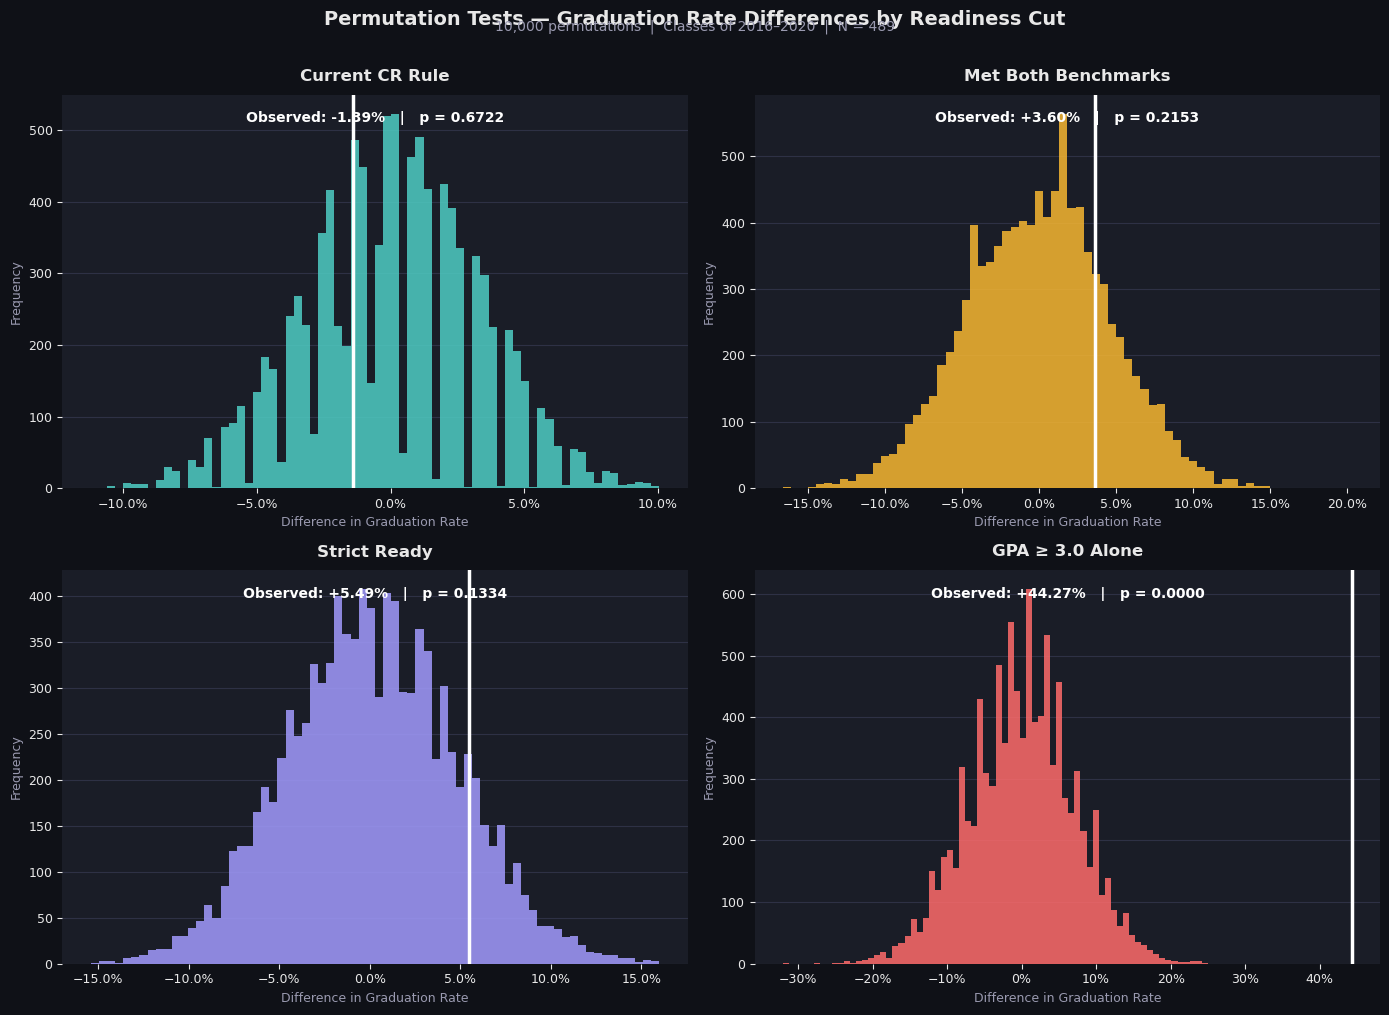

In [4]:
np.random.seed(42)
 
# ── Permutation Test Function ─────────────────────────────────────────────────
def permutation_test(group_flag, outcomes, n_permutations=10_000):
    observed = outcomes[group_flag].mean() - outcomes[~group_flag].mean()
    n_pos    = group_flag.sum()
    perm_diffs = np.array([
        np.random.permutation(outcomes)[:n_pos].mean() -
        np.random.permutation(outcomes)[n_pos:].mean()
        for _ in range(n_permutations)
    ])
    p_value = (perm_diffs >= observed).mean()
    return observed, perm_diffs, p_value
 
# ── Define Four Groups ────────────────────────────────────────────────────────
graduated = cohort["Graduated"].values
 
tests = {
    "Current CR Rule":   cohort["College_Ready"] == "Yes",
    "Met Both Benchmarks": cohort["Met_Both_Benchmarks"] == "Yes",
    "Strict Ready":      cohort["Strict_Ready"],
    "GPA ≥ 3.0 Alone":  cohort["GPA"] >= 3.0,
}
 
results = {}
for label, flag in tests.items():
    obs, perms, p = permutation_test(flag.values, graduated.astype(float))
    results[label] = {"observed": obs, "perms": perms, "p_value": p}
 
# ── Print Results ─────────────────────────────────────────────────────────────
SEP = "=" * 60
print(f"\n{SEP}")
print("  PERMUTATION TEST RESULTS  (10,000 permutations)")
print(SEP)
print(f"  {'Cut':<24} {'Obs. Diff':>10}   {'p-value':>8}   {'Conclusion'}")
print(f"  {'-'*24} {'-'*10}   {'-'*8}   {'-'*20}")
for label, res in results.items():
    conclusion = "Fail to reject H₀" if res["p_value"] > 0.05 else "Reject H₀"
    print(f"  {label:<24} {res['observed']*100:>+9.2f}%   {res['p_value']:>8.4f}   {conclusion}")
print(SEP + "\n")
 
# ── Plot ──────────────────────────────────────────────────────────────────────
BG       = "#0f1117"
PANEL_BG = "#1a1d27"
TEXT     = "#e8e8e8"
SUBTEXT  = "#9a9ab0"
COLORS   = ["#4ecdc4", "#f7b731", "#a29bfe", "#ff6b6b"]
 
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor(BG)
 
for ax, (label, res), color in zip(axes.flat, results.items(), COLORS):
    ax.set_facecolor(PANEL_BG)
    ax.hist(res["perms"] * 100, bins=70, color=color,
            alpha=0.85, edgecolor="none", zorder=3)
    ax.axvline(res["observed"] * 100, color="white",
               linewidth=2.5, zorder=5)
    ax.text(0.5, 0.93, f"Observed: {res['observed']*100:+.2f}%   |   p = {res['p_value']:.4f}",
            transform=ax.transAxes, ha="center",
            color="white", fontsize=10, fontweight="bold")
    ax.set_title(label, color=TEXT, fontsize=12, fontweight="bold", pad=10)
    ax.set_xlabel("Difference in Graduation Rate", color=SUBTEXT, fontsize=9)
    ax.set_ylabel("Frequency", color=SUBTEXT, fontsize=9)
    ax.tick_params(colors=TEXT, labelsize=9)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.yaxis.grid(True, color="#2e3145", linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
 
fig.suptitle("Permutation Tests — Graduation Rate Differences by Readiness Cut",
             color=TEXT, fontsize=14, fontweight="bold", y=1.01)
fig.text(0.5, 0.99, "10,000 permutations  |  Classes of 2016–2020  |  N = 489",
         ha="center", color=SUBTEXT, fontsize=10)
 
plt.tight_layout()
plt.savefig("permutation_tests.png", dpi=180, bbox_inches="tight", facecolor=BG)
plt.show()

### Permutation Test — Results & Interpretation

Running the permutation test across four readiness cuts produces a clear and decisive picture.

Current College Readeinss Rule confirms what we already found. An observed difference of -1.39% with p = 0.6722 — the label is noise. 67% of random shuffles produce a difference as large or larger than what the actual designation achieves. Met Both Benchmarks moves in the right direction at +3.60% but p = 0.2153 means roughly one in five random shuffles still beats it. There is a hint of signal but nothing we can act on with confidence. Strict Ready — both benchmarks and GPA ≥ 3.0 — produces the strongest benchmark-inclusive result at +5.49% with p = 0.1334. The observed line sits
in the tail of the null distribution but doesn't clear the threshold. A more stringent readiness rule is moving the needle, but not enough.

GPA ≥ 3.0 Alone is in a different category entirely. An observed difference of +44.27% with p = 0.0000 means that in 10,000 random shuffles, not a single one came close to producing what GPA alone achieves. The observed line in the plot sits completely outside the null distribution. This is not a marginal finding — it is overwhelming.

The pattern across the four tests is unambiguous. Every point of predictive power in the College Ready designation comes from GPA. The benchmark component adds nothing — and in the current formulation, actively dilutes the signal by forcing GPA into a binary threshold and pairing it with a variable that carries no independent predictive weight.

GPA ≥ 3.0 alone is a stronger predictor of college graduation than any version of the College Ready rule tested, including the strictest formulation that requires both benchmarks and a 3.0 GPA.

### Step 4 — Bootstrap Confidence Intervals

The permutation tests told us that GPA alone drives whatever predictive signal exists, and that the current College Ready designation carries none. Bootstrap confidence intervals tell us something different but complementary — how stable are the graduation rates themselves across all four cuts?

Where the permutation test asked "is this relationship real?", bootstrapping asks "how much would these rates move if the population looked slightly different?" We resample the data with replacement thousands of times and calculate the graduation rate on each resample. The spread of those rates gives us a confidence interval around each group's true rate. 

We build intervals for the same four cuts tested in the permutation analysis:

- Current College Ready rule (GPA ≥ 3.0 + at least 1 benchmark)
- Met Both Benchmarks
- Strict Ready (Met Both + GPA ≥ 3.0)
- GPA ≥ 3.0 Alone

For each cut we report the graduation rate and 95% confidence interval for both the positive and negative groups, and the interval around the difference between them. Overlapping intervals confirm the null. A difference interval that does not cross zero indicates a stable, directional effect.


  BOOTSTRAP CONFIDENCE INTERVALS  (95%, n=10,000)

  Current CR Rule
  --------------------------------------------------
  Group                     Mean   95% CI
  Positive                 45.9%   [39.8%, 52.0%]
  Negative                 47.3%   [40.7%, 53.5%]
  Difference               -1.3%   [-10.0%, 7.6%]

  Met Both Benchmarks
  --------------------------------------------------
  Group                     Mean   95% CI
  Positive                 49.5%   [39.4%, 59.6%]
  Negative                 45.9%   [41.0%, 51.0%]
  Difference               +3.6%   [-7.5%, 14.7%]

  Strict Ready
  --------------------------------------------------
  Group                     Mean   95% CI
  Positive                 51.0%   [41.5%, 60.6%]
  Negative                 45.6%   [40.8%, 50.4%]
  Difference               +5.4%   [-5.7%, 16.6%]

  GPA ≥ 3.0 Alone
  --------------------------------------------------
  Group                     Mean   95% CI
  Positive                 50.8%   [46.0%,

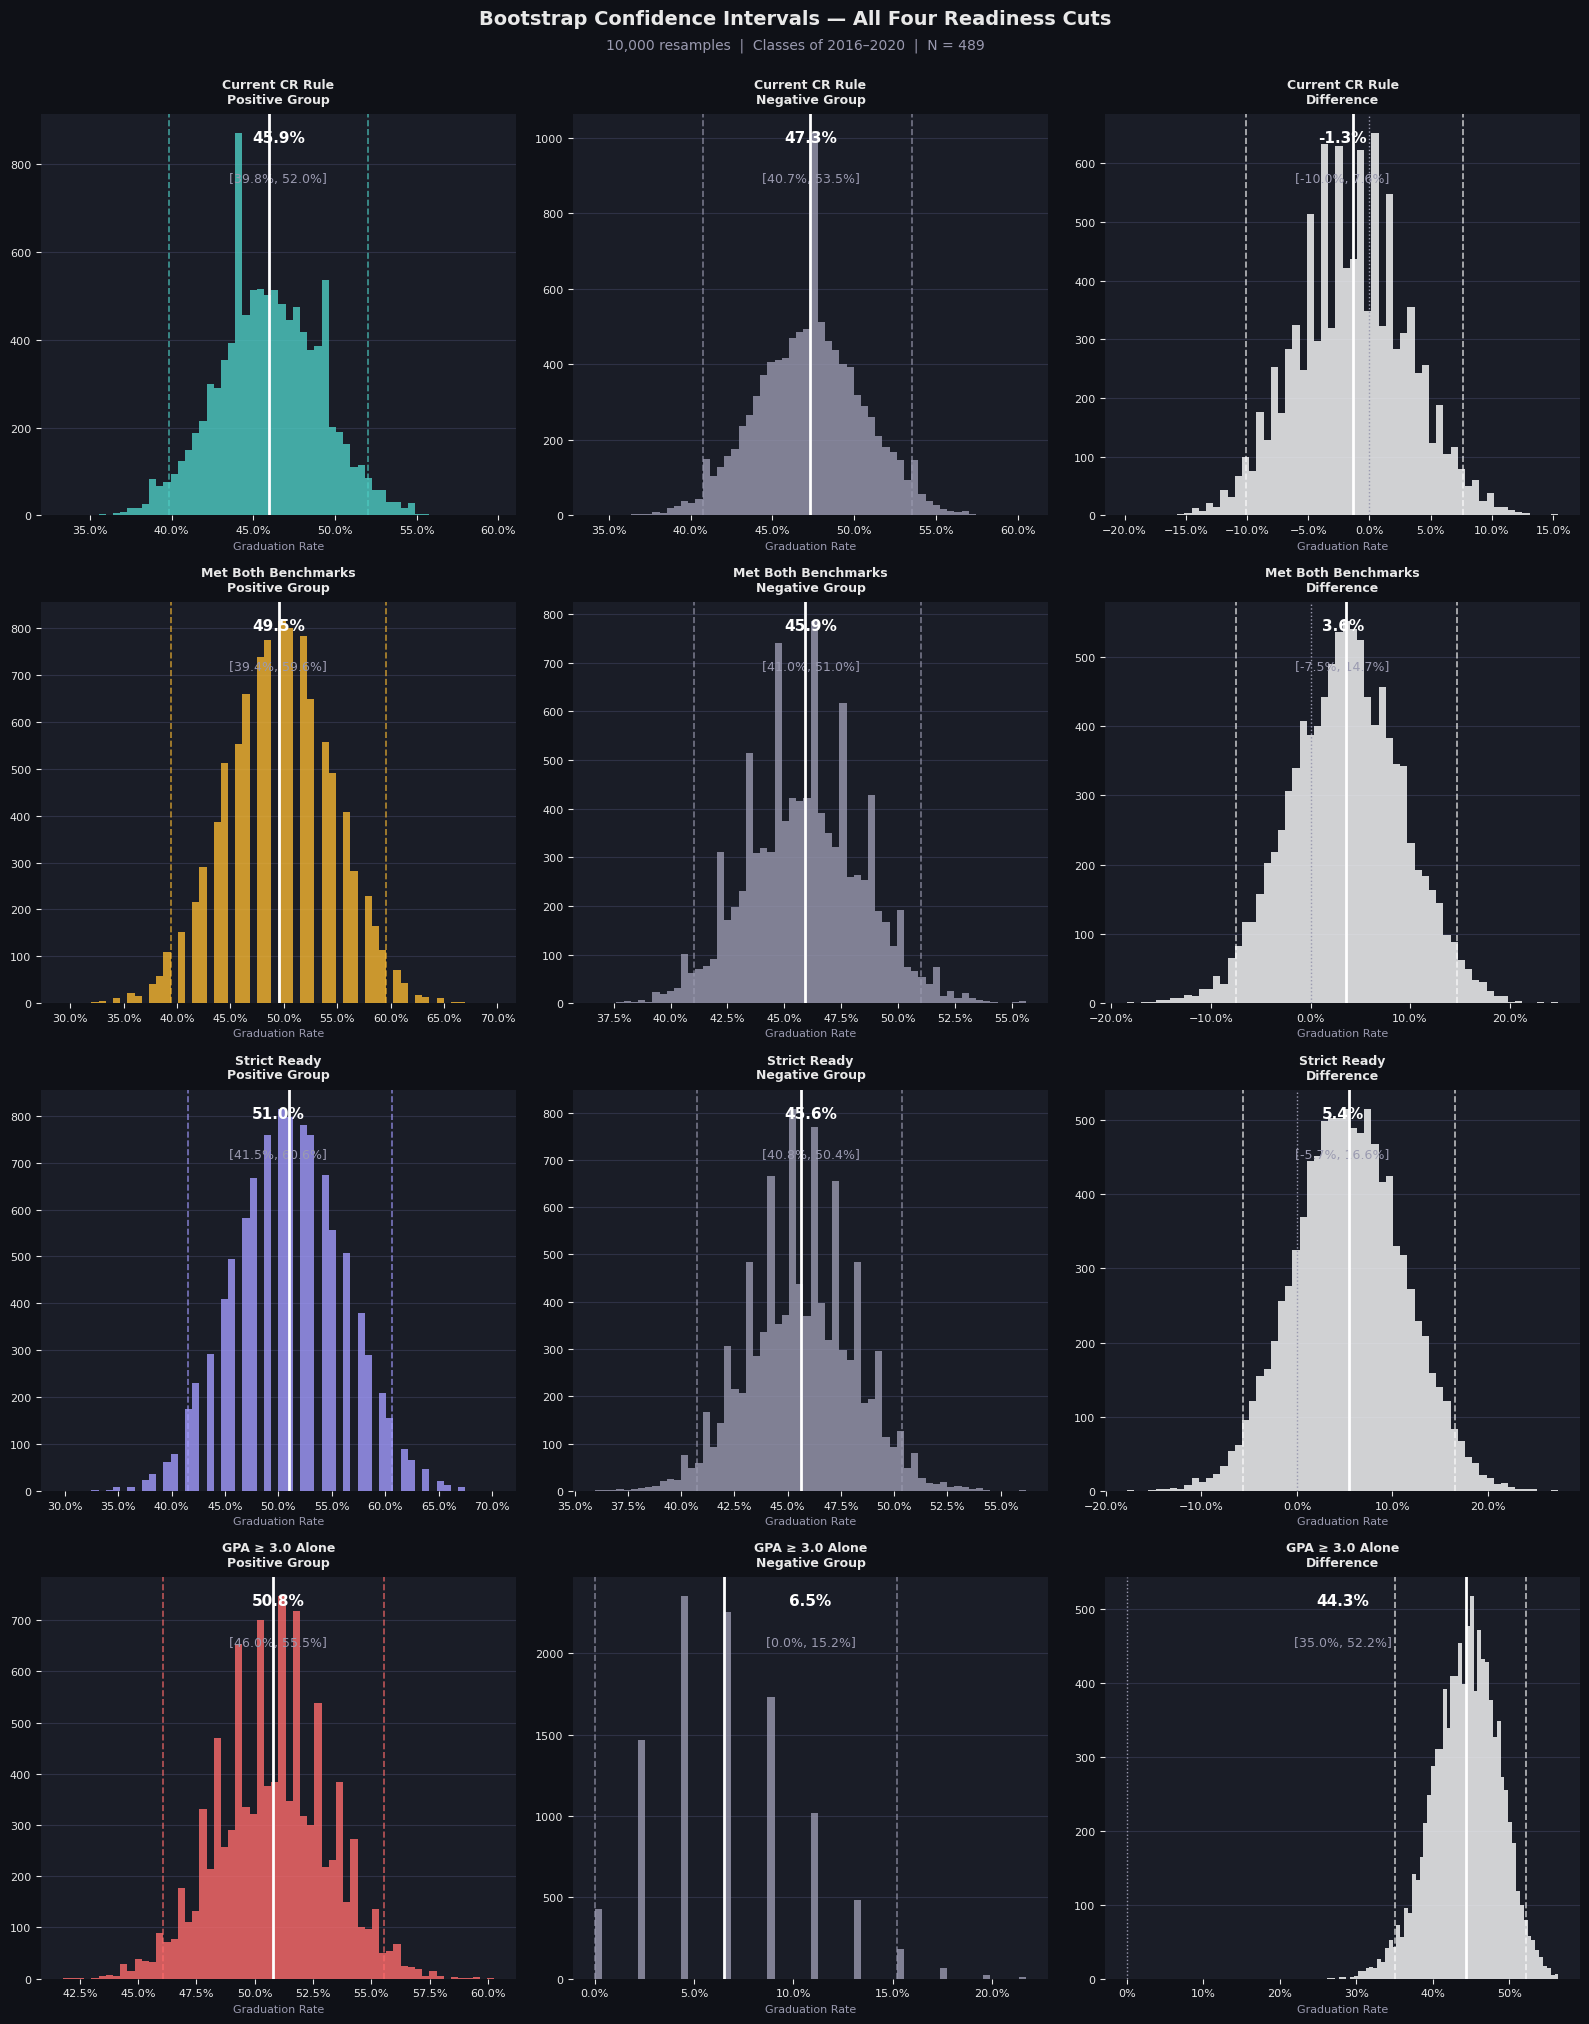

In [5]:
np.random.seed(42)
 
# ── Bootstrap Function ────────────────────────────────────────────────────────
def bootstrap_rate(data, n_boot=10_000):
    return np.array([
        np.random.choice(data, size=len(data), replace=True).mean()
        for _ in range(n_boot)
    ])
 
def ci(boot, level=0.95):
    alpha = (1 - level) / 2
    return np.percentile(boot, [alpha * 100, (1 - alpha) * 100])
 
# ── Define Four Cuts ──────────────────────────────────────────────────────────
cuts = {
    "Current CR Rule":      cohort["College_Ready"] == "Yes",
    "Met Both Benchmarks":  cohort["Met_Both_Benchmarks"] == "Yes",
    "Strict Ready":         cohort["Strict_Ready"],
    "GPA ≥ 3.0 Alone":     cohort["GPA"] >= 3.0,
}
 
graduated = cohort["Graduated"].values.astype(float)
boot_results = {}
 
for label, flag in cuts.items():
    pos  = bootstrap_rate(graduated[flag.values])
    neg  = bootstrap_rate(graduated[~flag.values])
    diff = pos - neg
    boot_results[label] = {
        "pos": pos,  "ci_pos":  ci(pos),
        "neg": neg,  "ci_neg":  ci(neg),
        "diff": diff, "ci_diff": ci(diff),
    }
 
# ── Print Results ─────────────────────────────────────────────────────────────
SEP = "=" * 65
print(f"\n{SEP}")
print("  BOOTSTRAP CONFIDENCE INTERVALS  (95%, n=10,000)")
print(SEP)
for label, res in boot_results.items():
    print(f"\n  {label}")
    print(f"  {'-'*50}")
    print(f"  {'Group':<22} {'Mean':>7}   {'95% CI'}")
    print(f"  {'Positive':<22} {res['pos'].mean()*100:>6.1f}%   "
          f"[{res['ci_pos'][0]*100:.1f}%, {res['ci_pos'][1]*100:.1f}%]")
    print(f"  {'Negative':<22} {res['neg'].mean()*100:>6.1f}%   "
          f"[{res['ci_neg'][0]*100:.1f}%, {res['ci_neg'][1]*100:.1f}%]")
    print(f"  {'Difference':<22} {res['diff'].mean()*100:>+6.1f}%   "
          f"[{res['ci_diff'][0]*100:.1f}%, {res['ci_diff'][1]*100:.1f}%]")
print(f"\n{SEP}\n")
 
# ── Plot ──────────────────────────────────────────────────────────────────────
BG       = "#0f1117"
PANEL_BG = "#1a1d27"
TEXT     = "#e8e8e8"
SUBTEXT  = "#9a9ab0"
COLORS   = ["#4ecdc4", "#f7b731", "#a29bfe", "#ff6b6b"]
 
fig, axes = plt.subplots(4, 3, figsize=(16, 20))
fig.patch.set_facecolor(BG)
 
for row, (label, res), row_color in zip(axes, boot_results.items(), COLORS):
    configs = [
        (res["pos"],  res["ci_pos"],  row_color, "Positive Group"),
        (res["neg"],  res["ci_neg"],  "#9a9ab0",  "Negative Group"),
        (res["diff"], res["ci_diff"], "white",    "Difference"),
    ]
    for ax, (boot, interval, color, sublabel) in zip(row, configs):
        ax.set_facecolor(PANEL_BG)
        ax.hist(boot * 100, bins=60, color=color, alpha=0.8, edgecolor="none", zorder=3)
        ax.axvline(boot.mean() * 100, color="white", linewidth=2, zorder=5)
        ax.axvline(interval[0] * 100, color=color, linewidth=1.2,
                   linestyle="--", zorder=5, alpha=0.7)
        ax.axvline(interval[1] * 100, color=color, linewidth=1.2,
                   linestyle="--", zorder=5, alpha=0.7)
        if sublabel == "Difference":
            ax.axvline(0, color=SUBTEXT, linewidth=1, linestyle=":", zorder=4)
        ax.text(0.5, 0.93, f"{boot.mean()*100:.1f}%",
                transform=ax.transAxes, ha="center",
                color="white", fontsize=11, fontweight="bold")
        ax.text(0.5, 0.83, f"[{interval[0]*100:.1f}%, {interval[1]*100:.1f}%]",
                transform=ax.transAxes, ha="center", color=SUBTEXT, fontsize=9)
        ax.set_title(f"{label}\n{sublabel}", color=TEXT, fontsize=9,
                     fontweight="bold", pad=8)
        ax.set_xlabel("Graduation Rate", color=SUBTEXT, fontsize=8)
        ax.tick_params(colors=TEXT, labelsize=8)
        ax.xaxis.set_major_formatter(mtick.PercentFormatter())
        for spine in ax.spines.values():
            spine.set_visible(False)
        ax.yaxis.grid(True, color="#2e3145", linewidth=0.8, zorder=0)
        ax.set_axisbelow(True)
 
fig.suptitle("Bootstrap Confidence Intervals — All Four Readiness Cuts",
             color=TEXT, fontsize=14, fontweight="bold", y=1.01)
fig.text(0.5, 0.99, "10,000 resamples  |  Classes of 2016–2020  |  N = 489",
         ha="center", color=SUBTEXT, fontsize=10)
 
plt.tight_layout()
plt.savefig("bootstrap_ci.png", dpi=180, bbox_inches="tight", facecolor=BG)
plt.show()

### Bootstrap Confidence Intervals — Results & Interpretation

The bootstrap results across all four cuts tell a consistent and increasingly clear story.

Current CR Rule produces intervals that overlap almost entirely — 45.9% [39.8%, 52.0%] for designated students versus 47.3% [40.7%, 53.5%] for those not designated. The difference interval of -1.3% [-10.0%, 7.6%] crosses zero comfortably. No stable effect in either direction.

Met Both Benchmarks widens the gap slightly — 49.5% versus 45.9% — but the difference interval of +3.6% [-7.5%, 14.7%] still crosses zero. The two groups' intervals overlap substantially. There is movement in the right direction but nothing stable enough to act on. Strict Ready produces the best benchmark-inclusive result — 51.0% [41.5%, 60.6%] versus 45.6% [40.8%, 50.4%] — but the difference interval of +5.4% [-5.7%, 16.6%] still crosses zero. Note also that the positive group's interval is wide, spanning nearly 20 percentage points, reflecting the smaller sample size of students who meet the stricter criteria. GPA ≥ 3.0 Alone is categorically different from every other cut examined.

Students with a GPA of 3.0 or above graduated at 50.8% [46.0%, 55.5%]. 

Students below a 3.0 graduated at just 6.5% [0.0%, 15.2%]. 

The difference of +44.3% carries a confidence interval of [35.0%, 52.2%] — wide but entirely above zero. Even at the lower bound of the interval, GPA alone produces a 35 percentage point separation between the two groups. The negative group's interval nearly touching zero is striking. Sub-3.0 GPA students in this population have an extremely low probability of graduating within six years. That finding is stable across resamples. The pattern is unambiguous across all four tests. Benchmark attainment in any form — one, both, paired with GPA — produces unstable, overlapping intervals that cannot support any reliable conclusion about graduation likelihood. GPA operates on a completely different scale. It is not a stronger predictor. It is the only predictor.

### Step 5 — Logistic Regression

The permutation tests and bootstrap intervals established that GPA alone drives whatever predictive signal exists, and that benchmark attainment in any form adds nothing meaningful. Logistic regression lets us confirm this with a parametric model and quantify each predictor's independent contribution to the likelihood of graduating.

We fit four models to match the cuts tested throughout the analysis:

Model 1 — Binary Flag
Uses College Ready (Yes/No) as a single predictor. Formal baseline.

Model 2 — Components
Uses GPA as a continuous variable and Met Benchmark (Yes/No) as a binary variable independently. Separates what the current rule collapses together.

Model 3 — Strict Components
Uses GPA as a continuous variable and Met Both Benchmarks (Yes/No) as a binary variable. Tests whether the stricter benchmark definition changes the picture.

Model 4 — GPA Alone
Uses only GPA as a continuous predictor. Given the resampling findings, this is expected to be the strongest model. We report coefficients, odds ratios, accuracy, and ROC-AUC for all four. Conclusions should confirm with a parametric method what resampling suggested, not simply assume it.

Because this is a full population, logistic regression is used here as a descriptive tool. Coefficients describe the structure of this population.We are not generalizing to an external group.


  MODEL 1 — BINARY FLAG (College Ready Yes/No)
  Coefficient (Ready):  -0.0541
  Odds Ratio:           0.9474
  Intercept:            -0.1080
  Accuracy:             53.4%
  ROC-AUC:              0.5070

  MODEL 2 — COMPONENTS (GPA + Benchmark)
  Coefficient (GPA):        +2.9515
  Odds Ratio (GPA):         19.1348
  Coefficient (Benchmark):  -0.4580
  Odds Ratio (Benchmark):   0.6325
  Intercept:                -9.9350
  Accuracy:                 69.9%
  ROC-AUC:                  0.7468



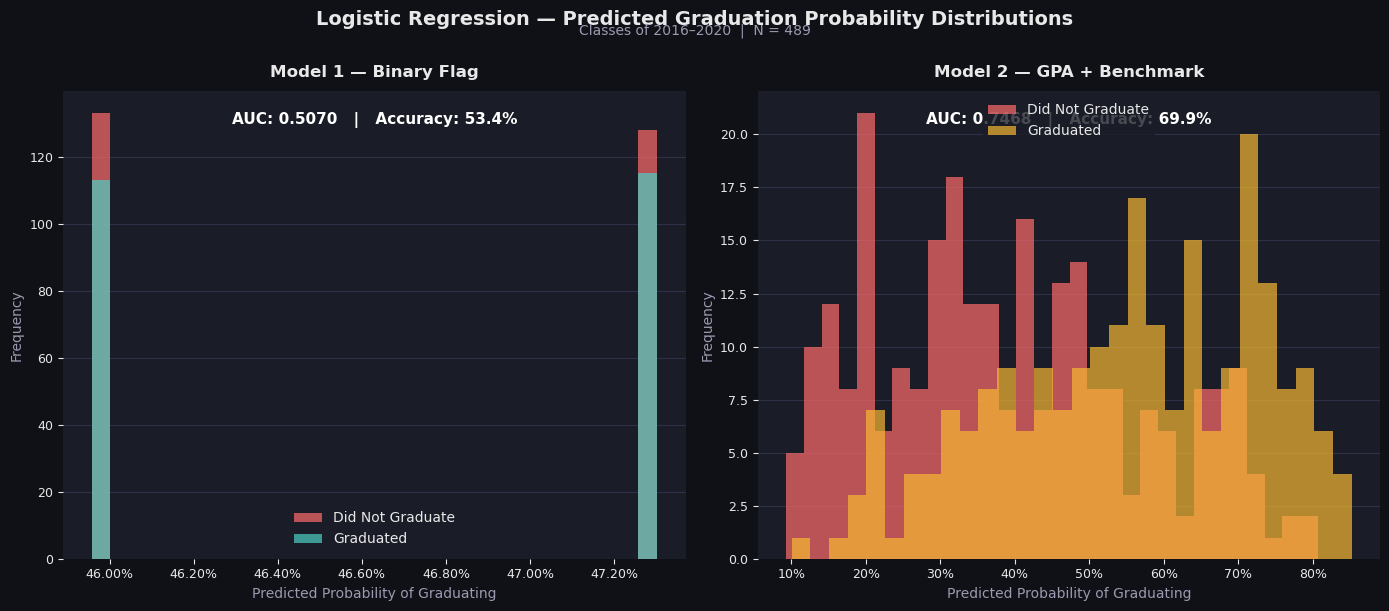

In [6]:


# ── Prepare Features ──────────────────────────────────────────────────────────
cohort_lr = cohort.dropna(subset=["GPA", "Met_Benchmark", "College_Ready", "Graduated"]).copy()

# Encode binary string columns
cohort_lr["Ready_enc"]     = (cohort_lr["College_Ready"] == "Yes").astype(int)
cohort_lr["Benchmark_enc"] = (cohort_lr["Met_Benchmark"] == "Yes").astype(int)
y = cohort_lr["Graduated"].astype(int)

# ── Model 1: Binary Flag ──────────────────────────────────────────────────────
X1 = cohort_lr[["Ready_enc"]]
m1 = LogisticRegression(random_state=42)
m1.fit(X1, y)
y_pred1 = m1.predict(X1)
y_prob1  = m1.predict_proba(X1)[:, 1]

# ── Model 2: Components ───────────────────────────────────────────────────────
X2 = cohort_lr[["GPA", "Benchmark_enc"]]
m2 = LogisticRegression(random_state=42)
m2.fit(X2, y)
y_pred2 = m2.predict(X2)
y_prob2  = m2.predict_proba(X2)[:, 1]

# ── Print Results ─────────────────────────────────────────────────────────────
SEP = "=" * 55

print(f"\n{SEP}")
print("  MODEL 1 — BINARY FLAG (College Ready Yes/No)")
print(SEP)
print(f"  Coefficient (Ready):  {m1.coef_[0][0]:>+.4f}")
print(f"  Odds Ratio:           {np.exp(m1.coef_[0][0]):.4f}")
print(f"  Intercept:            {m1.intercept_[0]:>+.4f}")
print(f"  Accuracy:             {accuracy_score(y, y_pred1)*100:.1f}%")
print(f"  ROC-AUC:              {roc_auc_score(y, y_prob1):.4f}")

print(f"\n{SEP}")
print("  MODEL 2 — COMPONENTS (GPA + Benchmark)")
print(SEP)
print(f"  Coefficient (GPA):        {m2.coef_[0][0]:>+.4f}")
print(f"  Odds Ratio (GPA):         {np.exp(m2.coef_[0][0]):.4f}")
print(f"  Coefficient (Benchmark):  {m2.coef_[0][1]:>+.4f}")
print(f"  Odds Ratio (Benchmark):   {np.exp(m2.coef_[0][1]):.4f}")
print(f"  Intercept:                {m2.intercept_[0]:>+.4f}")
print(f"  Accuracy:                 {accuracy_score(y, y_pred2)*100:.1f}%")
print(f"  ROC-AUC:                  {roc_auc_score(y, y_prob2):.4f}")
print(SEP + "\n")

# ── Plot ──────────────────────────────────────────────────────────────────────
BG       = "#0f1117"
PANEL_BG = "#1a1d27"
TEXT     = "#e8e8e8"
SUBTEXT  = "#9a9ab0"
COL1     = "#4ecdc4"
COL2     = "#f7b731"

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(BG)

for ax, y_prob, title, color in zip(
    axes,
    [y_prob1, y_prob2],
    ["Model 1 — Binary Flag", "Model 2 — GPA + Benchmark"],
    [COL1, COL2]
):
    ax.set_facecolor(PANEL_BG)

    # Predicted probability distributions by actual outcome
    ax.hist(y_prob[y == 0], bins=30, alpha=0.7, color="#ff6b6b",
            label="Did Not Graduate", edgecolor="none", zorder=3)
    ax.hist(y_prob[y == 1], bins=30, alpha=0.7, color=color,
            label="Graduated", edgecolor="none", zorder=3)

    auc = roc_auc_score(y, y_prob)
    acc = accuracy_score(y, y_prob > 0.5) * 100

    ax.text(0.5, 0.93, f"AUC: {auc:.4f}   |   Accuracy: {acc:.1f}%",
            transform=ax.transAxes, ha="center",
            color="white", fontsize=11, fontweight="bold")

    ax.set_title(title, color=TEXT, fontsize=12, fontweight="bold", pad=10)
    ax.set_xlabel("Predicted Probability of Graduating", color=SUBTEXT, fontsize=10)
    ax.set_ylabel("Frequency", color=SUBTEXT, fontsize=10)
    ax.tick_params(colors=TEXT, labelsize=9)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    ax.legend(facecolor=PANEL_BG, edgecolor="none", labelcolor=TEXT, fontsize=10)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.yaxis.grid(True, color="#2e3145", linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)

fig.suptitle("Logistic Regression — Predicted Graduation Probability Distributions",
             color=TEXT, fontsize=14, fontweight="bold", y=1.01)
fig.text(0.5, 0.97, "Classes of 2016–2020  |  N = 489",
         ha="center", color=SUBTEXT, fontsize=10)

plt.tight_layout()
plt.savefig("logistic_regression.png", dpi=180, bbox_inches="tight", facecolor=BG)
plt.show()


  MODEL 1 — BINARY FLAG
  Coefficient (Ready_enc         ) -0.0541   OR: 0.9474
  Intercept:                       -0.1080
  Accuracy:                        53.4%
  ROC-AUC:                         0.5070

  MODEL 2 — GPA + BENCHMARK
  Coefficient (GPA               ) +2.9515   OR: 19.1348
  Coefficient (Benchmark_enc     ) -0.4580   OR: 0.6325
  Intercept:                       -9.9350
  Accuracy:                        69.9%
  ROC-AUC:                         0.7468

  MODEL 3 — GPA + BOTH
  Coefficient (GPA               ) +2.9294   OR: 18.7169
  Coefficient (Both_enc          ) -0.1399   OR: 0.8695
  Intercept:                       -10.0815
  Accuracy:                        66.9%
  ROC-AUC:                         0.7375

  MODEL 4 — GPA ALONE
  Coefficient (GPA               ) +2.8987   OR: 18.1513
  Intercept:                       -10.0052
  Accuracy:                        67.3%
  ROC-AUC:                         0.7369



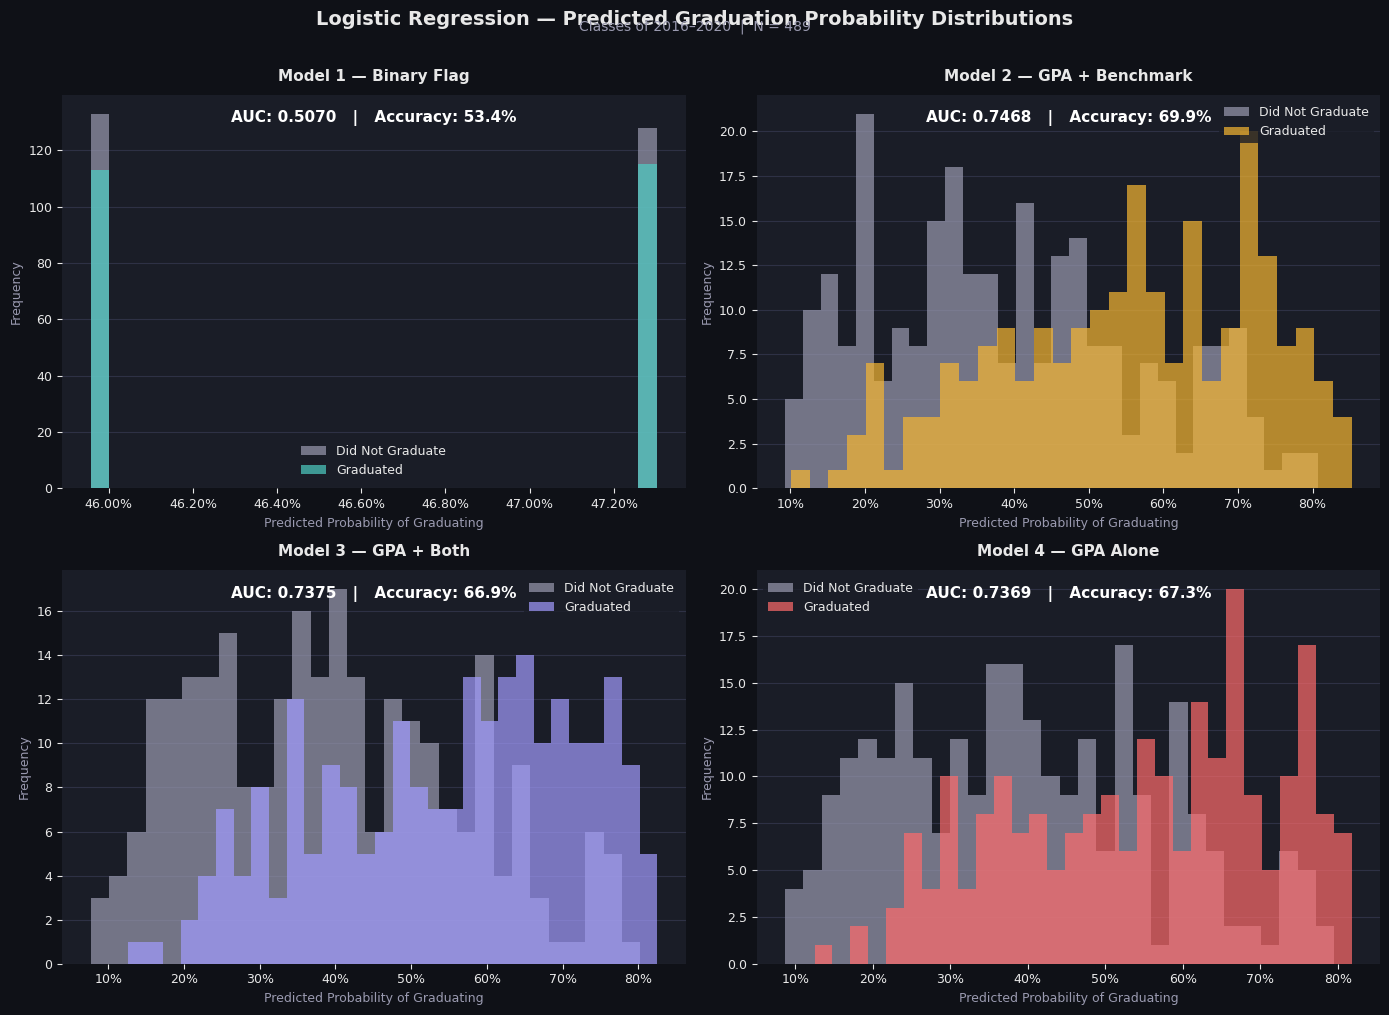

In [7]:
# ── Prepare Features ──────────────────────────────────────────────────────────
cohort_lr = cohort.dropna(subset=["GPA", "Met_Benchmark", "Met_Both_Benchmarks",
                                   "College_Ready", "Graduated"]).copy()
 
cohort_lr["Ready_enc"]     = (cohort_lr["College_Ready"] == "Yes").astype(int)
cohort_lr["Benchmark_enc"] = (cohort_lr["Met_Benchmark"] == "Yes").astype(int)
cohort_lr["Both_enc"]      = (cohort_lr["Met_Both_Benchmarks"] == "Yes").astype(int)
y = cohort_lr["Graduated"].astype(int)
 
# ── Fit Models ────────────────────────────────────────────────────────────────
models = {
    "Model 1 — Binary Flag":       cohort_lr[["Ready_enc"]],
    "Model 2 — GPA + Benchmark":   cohort_lr[["GPA", "Benchmark_enc"]],
    "Model 3 — GPA + Both":        cohort_lr[["GPA", "Both_enc"]],
    "Model 4 — GPA Alone":         cohort_lr[["GPA"]],
}
 
fitted = {}
for name, X in models.items():
    m = LogisticRegression(random_state=42)
    m.fit(X, y)
    fitted[name] = {
        "model":  m,
        "X":      X,
        "y_pred": m.predict(X),
        "y_prob": m.predict_proba(X)[:, 1],
    }
 
# ── Print Results ─────────────────────────────────────────────────────────────
SEP = "=" * 58
 
for name, res in fitted.items():
    m     = res["model"]
    print(f"\n{SEP}")
    print(f"  {name.upper()}")
    print(SEP)
    for i, feat in enumerate(models[name].columns):
        coef = m.coef_[0][i]
        print(f"  Coefficient ({feat:<18}) {coef:>+.4f}   OR: {np.exp(coef):.4f}")
    print(f"  Intercept:                       {m.intercept_[0]:>+.4f}")
    print(f"  Accuracy:                        {accuracy_score(y, res['y_pred'])*100:.1f}%")
    print(f"  ROC-AUC:                         {roc_auc_score(y, res['y_prob']):.4f}")
print(SEP + "\n")
 
# ── Plot ──────────────────────────────────────────────────────────────────────
BG       = "#0f1117"
PANEL_BG = "#1a1d27"
TEXT     = "#e8e8e8"
SUBTEXT  = "#9a9ab0"
COLORS   = ["#4ecdc4", "#f7b731", "#a29bfe", "#ff6b6b"]
 
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor(BG)
 
for ax, (name, res), color in zip(axes.flat, fitted.items(), COLORS):
    ax.set_facecolor(PANEL_BG)
    ax.hist(res["y_prob"][y == 0], bins=30, alpha=0.7, color="#9a9ab0",
            label="Did Not Graduate", edgecolor="none", zorder=3)
    ax.hist(res["y_prob"][y == 1], bins=30, alpha=0.7, color=color,
            label="Graduated", edgecolor="none", zorder=3)
    auc = roc_auc_score(y, res["y_prob"])
    acc = accuracy_score(y, res["y_prob"] > 0.5) * 100
    ax.text(0.5, 0.93, f"AUC: {auc:.4f}   |   Accuracy: {acc:.1f}%",
            transform=ax.transAxes, ha="center",
            color="white", fontsize=11, fontweight="bold")
    ax.set_title(name, color=TEXT, fontsize=11, fontweight="bold", pad=10)
    ax.set_xlabel("Predicted Probability of Graduating", color=SUBTEXT, fontsize=9)
    ax.set_ylabel("Frequency", color=SUBTEXT, fontsize=9)
    ax.tick_params(colors=TEXT, labelsize=9)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    ax.legend(facecolor=PANEL_BG, edgecolor="none", labelcolor=TEXT, fontsize=9)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.yaxis.grid(True, color="#2e3145", linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
 
fig.suptitle("Logistic Regression — Predicted Graduation Probability Distributions",
             color=TEXT, fontsize=14, fontweight="bold", y=1.01)
fig.text(0.5, 0.99, "Classes of 2016–2020  |  N = 489",
         ha="center", color=SUBTEXT, fontsize=10)
 
plt.tight_layout()
plt.savefig("logistic_regression.png", dpi=180, bbox_inches="tight", facecolor=BG)
plt.show()

### Logistic Regression — Results & Interpretation

Model 1 — Binary Flag
AUC of 0.5070. Two vertical bars. The model assigns virtually the same probability to every student regardless of their designation. The coefficient of -0.054 with an odds ratio of 0.95 means the label carries no directional information. This formally confirms what the permutation test and bootstrap intervals already showed.

Models 2, 3, and 4 — The GPA Story
Separating the components changes everything — and the results across the three GPA-inclusive models are remarkably consistent. The GPA coefficient barely moves across all three models: +2.95, +2.93, +2.90. The odds ratio sits around 18–19 in each case, meaning that for every one-point increase in GPA, a student's odds of graduating within six years increase by a factor of roughly 18, regardless of what else is in the model.That stability is itself a finding — GPA's effect is not sensitive to what other variables are included.

Benchmark attainment tells the opposite story. In Model 2, meeting at least one benchmark carries a negative coefficient (-0.458, OR: 0.63) — meaning= students who met a benchmark were less likely to graduate than those who did not, once GPA is held constant. In Model 3, switching to the stricter Met Both Benchmarks variable produces a coefficient of -0.140 (OR: 0.87). Still negative, still in the wrong direction, and now even closer to zero.

Model 4 — GPA alone — achieves an AUC of 0.7369. Model 2, which adds a benchmark variable, reaches 0.7468. The difference is 0.0099. Model 3, with the stricter benchmark, lands at 0.7375 — a gain of 0.0006 over GPA alone. Adding benchmark attainment in any form produces no meaningful improvement in predictive performance.

The conclusion is unambiguous. GPA is the only variable in this dataset that carries real predictive information about college graduation. Benchmark attainment — whether one or both, whether alone or paired with GPA — adds nothing, and in every model tested pulls in the wrong direction.

The current College Ready designation takes the one variable that predicts graduation, collapses it into a binary threshold, and combines it with a variable that actively works against the prediction. The result is a metric that performs worse than either component used correctly.

### Step 6 — Projected Graduation Rates: Classes of 2022–2025

The analysis cohort established that GPA is the only meaningful predictor of college graduation within six years in this population. We now apply

Model 4 — GPA alone — to the Classes of 2022–2025 to generate projected graduation likelihoods for each student and aggregate projected rates for each cohort.

These are not observed outcomes. Students in the 2022–2025 cohort are between one and four years post-graduation and do not yet have final college completion records. The projections represent the expected graduation rate for each class given the GPA distribution of its students and the relationship between GPA and graduation observed in the 2016–2020 cohort.

A few important caveats:

The model was trained on 489 students across five graduating classes. It captures the average relationship between GPA and graduation in this population but cannot account for individual circumstances, institutional changes, or shifts in the post-secondary landscape between cohorts.

The 2022–2025 students attended high school during and after the COVID-19 pandemic. Any systematic effects on GPA distributions or college-going behavior during that period are not controlled for. Projections should be interpreted as probabilistic benchmarks, not forecasts. They answer the question: given what we know about GPA and graduation in this school's history, what should we expect from these cohorts?


  OBSERVED GRADUATION RATES — Classes of 2016–2020
  Class        N    Observed Rate
  -------- -----   --------------
  2016        71            42.3%
  2017        85            51.8%
  2018        80            47.5%
  2019       129            45.0%
  2020       124            46.8%

  PROJECTED GRADUATION RATES — Classes of 2022–2025
  Based on Model 4 (GPA Alone) trained on 2016–2020
  Class        N    Mean GPA   Projected Rate
  -------- -----   ---------   --------------
  2022       104        3.45            51.2%
  2023       115        3.31            42.1%
  2024       100        3.26            38.7%
  2025       100        3.30            40.6%



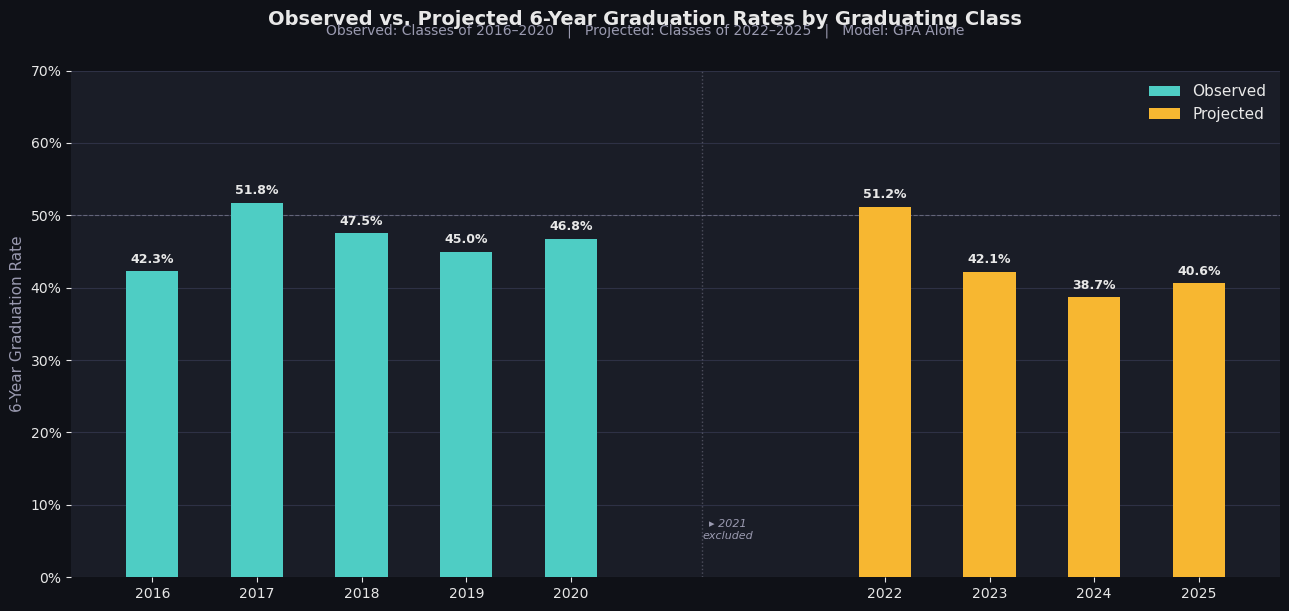

In [8]:
# ── Prediction Cohort ─────────────────────────────────────────────────────────
prediction_years = ["2022", "2023", "2024", "2025"]
pred_cohort = df[df["Class_Of"].isin(prediction_years)].dropna(subset=["GPA"]).copy()
 
# ── Apply Model 4 (GPA Alone) ─────────────────────────────────────────────────
# Model was fit on the 2016–2020 cohort using GPA as the sole predictor.
# We use it here to generate per-student graduation probabilities.
 
model = fitted["Model 4 — GPA Alone"]["model"]
pred_cohort["Grad_Probability"] = model.predict_proba(pred_cohort[["GPA"]])[:, 1]
 
# ── Class-Level Projections ───────────────────────────────────────────────────
class_proj = pred_cohort.groupby("Class_Of").agg(
    N              = ("GPA", "count"),
    Mean_GPA       = ("GPA", "mean"),
    Projected_Rate = ("Grad_Probability", "mean")
).reset_index()
 
# Also include observed 2016–2020 rates for reference
observed_rates = {
    "2016": (30/71,  71),
    "2017": (44/85,  85),
    "2018": (38/80,  80),
    "2019": (58/129, 129),
    "2020": (58/124, 124),
}
 
# ── Print Results ─────────────────────────────────────────────────────────────
SEP = "=" * 60
print(f"\n{SEP}")
print("  OBSERVED GRADUATION RATES — Classes of 2016–2020")
print(SEP)
print(f"  {'Class':<8} {'N':>5}   {'Observed Rate':>14}")
print(f"  {'-'*8} {'-'*5}   {'-'*14}")
for year, (rate, n) in observed_rates.items():
    print(f"  {year:<8} {n:>5}   {rate*100:>13.1f}%")
print(SEP)
 
print(f"\n{SEP}")
print("  PROJECTED GRADUATION RATES — Classes of 2022–2025")
print(f"  Based on Model 4 (GPA Alone) trained on 2016–2020")
print(SEP)
print(f"  {'Class':<8} {'N':>5}   {'Mean GPA':>9}   {'Projected Rate':>14}")
print(f"  {'-'*8} {'-'*5}   {'-'*9}   {'-'*14}")
for _, row in class_proj.iterrows():
    print(f"  {row['Class_Of']:<8} {int(row['N']):>5}   "
          f"{row['Mean_GPA']:>9.2f}   {row['Projected_Rate']*100:>13.1f}%")
print(SEP + "\n")
 
# ── Plot ──────────────────────────────────────────────────────────────────────
BG       = "#0f1117"
PANEL_BG = "#1a1d27"
TEXT     = "#e8e8e8"
SUBTEXT  = "#9a9ab0"
OBS_COL  = "#4ecdc4"
PROJ_COL = "#f7b731"
 
fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(PANEL_BG)
 
obs_years  = list(observed_rates.keys())
obs_values = [v[0] * 100 for v in observed_rates.values()]
proj_years  = class_proj["Class_Of"].tolist()
proj_values = (class_proj["Projected_Rate"] * 100).tolist()
 
# Observed bars
x_obs = range(len(obs_years))
b1 = ax.bar(x_obs, obs_values, color=OBS_COL, width=0.5,
            zorder=3, edgecolor="none", label="Observed")
for bar, val in zip(b1, obs_values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.8,
            f"{val:.1f}%", ha="center", va="bottom",
            fontsize=9, color=TEXT, fontweight="bold")
 
# Gap marker
ax.text(5.5, 5, "▸ 2021\nexcluded", ha="center", va="bottom",
        color=SUBTEXT, fontsize=8, style="italic")
 
# Projected bars
x_proj = range(7, 7 + len(proj_years))
b2 = ax.bar(x_proj, proj_values, color=PROJ_COL, width=0.5,
            zorder=3, edgecolor="none", label="Projected")
for bar, val in zip(b2, proj_values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.8,
            f"{val:.1f}%", ha="center", va="bottom",
            fontsize=9, color=TEXT, fontweight="bold")
 
all_years  = obs_years + ["", ""] + proj_years
all_x      = list(range(len(obs_years))) + [5, 6] + list(range(7, 7 + len(proj_years)))
ax.set_xticks(list(range(len(obs_years))) + list(range(7, 7 + len(proj_years))))
ax.set_xticklabels(obs_years + proj_years, color=TEXT, fontsize=11)
 
ax.axhline(50, color=SUBTEXT, linewidth=0.8, linestyle="--", alpha=0.5, zorder=2)
ax.axvline(5.25, color=SUBTEXT, linewidth=1, linestyle=":", alpha=0.4, zorder=2)
 
ax.set_ylim(0, 70)
ax.set_ylabel("6-Year Graduation Rate", color=SUBTEXT, fontsize=11)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.tick_params(colors=TEXT, labelsize=10)
ax.legend(facecolor=PANEL_BG, edgecolor="none", labelcolor=TEXT, fontsize=11)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.yaxis.grid(True, color="#2e3145", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
 
fig.suptitle("Observed vs. Projected 6-Year Graduation Rates by Graduating Class",
             color=TEXT, fontsize=14, fontweight="bold", y=1.01)
fig.text(0.5, 0.97,
         "Observed: Classes of 2016–2020   |   Projected: Classes of 2022–2025   |   Model: GPA Alone",
         ha="center", color=SUBTEXT, fontsize=10)
 
plt.tight_layout()
plt.savefig("projection.png", dpi=180, bbox_inches="tight", facecolor=BG)
plt.show()

### Step 6 — Projected Graduation Rates: Results & Interpretation

Model 4, trained on GPA alone from the Classes of 2016–2020, was applied to the 419 students in the Classes of 2022–2025 to generate class-level projected graduation rates.

The projections track closely with each cohort's mean GPA. The Class of 2022 carries the strongest GPA distribution of the four prediction cohorts at a mean of 3.45 and projects at 51.2% — the only cohort expected to clear the 50% mark. The Classes of 2023, 2024, and 2025 cluster between 38.7% and 42.1%, consistent with mean GPAs between 3.26 and 3.31. Comparing projected rates to the observed 2016–2020 cohort, the 2022–2025 classes appear to be tracking slightly below the historical average of 46.7%. The Class of 2022 is the exception, projecting above that baseline. The remaining three cohorts project meaningfully below it, which aligns with their lower GPA distributions relative to prior classes.

These projections carry inherent uncertainty. The model explains a meaningful portion of the variation in graduation outcomes — AUC of 0.737 — but GPA alone cannot account for everything. Financial circumstances, institutional support, major selection, and life events all influence completion in ways this model cannot see. The projections are best understood as a prior — a reasonable expectation to update as actual outcomes become available over the next two to five years.

As each class reaches the six-year mark, comparing observed outcomes to these projections will provide a direct test of the model's predictive validity out of sample, and an ongoing lens for understanding how the school's college-going outcomes are evolving over time.

Data Sources

The dataset used in this analysis was compiled from four institutional and national data systems. All records were matched at the student level prior
to analysis.

Student Information System (SIS)
High school GPA and graduating class year were pulled directly from the school's SIS. GPA reflects the cumulative unweighted grade point average at the time of HS graduation.

College Board
SAT scores and subject-level benchmark attainment were sourced from College Board records. Benchmark thresholds reflect the College Board's definition of a 50% likelihood of earning at least a C in a corresponding first-year college course.

ACT
ACT scores were used for the Classes of 2016–2020. Subject-level benchmark attainment was evaluated against ACT-defined thresholds, which carry the same 50% likelihood definition as the SAT. Scores were concorded to SAT equivalents for consistency in reporting.

National Student Clearinghouse
College enrollment and completion outcomes (Column J, College Status) were sourced from the National Student Clearinghouse. The Clearinghouse tracks post-secondary enrollment and degree completion across participating institutions nationwide and serves as the standard source for college outcome reporting in K–12 contexts.

The Class of 2020 Clearinghouse data may not yet reflect final outcomes for all students, as this cohort reaches the six-year completion window in 2026. Results for this class should be interpreted accordingly.

### Summary & Conclusions

This analysis set out to answer one question: does the school's College Ready designation predict whether a student graduates from college within six years? The answer, supported by every method applied, is no.

What the Data Showed

The College Ready designation — GPA ≥ 3.0 and at least one ACT benchmark met — produced a graduation rate of 45.9% against 47.3% for non-designated students. A permutation test returned p = 0.6722. 

Bootstrap confidence intervals overlapped completely, with the difference interval centered at -1.3% and crossing zero by a wide margin. A logistic regression using the
binary flag as the sole predictor returned an AUC of 0.5070 — statistically indistinguishable from random assignment.

The quadrant analysis made the finding concrete. Of 489 students in the analysis cohort, the four possible combinations of designation and outcome were nearly equal in size — 23.1%, 27.2%, 23.5%, and 26.2%. More students were designated College Ready and did not graduate (133) than were designated College Ready and did graduate (113). Tightening the benchmark requirement to both subject areas, and pairing it with the GPA threshold, produced the highest graduation rate of any readiness cut tested at 51.1% — but still failed to clear statistical significance, and applied to only 94 of 489 students.

Where the Signal Actually Lives 
GPA alone tells a completely different story. A permutation test on GPA ≥ 3.0 returned p = 0.0000 — not a single one of 10,000 random shuffles produced a difference as large as the one observed. Students above a 3.0 graduated at 50.8% [46.0%, 55.5%]. Students below a 3.0 graduated at 6.5% [0.0%, 15.2%] — a difference of 44.3 percentage points with a confidence interval entirely above zero.
Logistic regression confirmed this across three GPA-inclusive models. The GPA coefficient was stable at approximately +2.90 to +2.95 regardless of what other variables were included, producing an odds ratio of roughly 18 — meaning each additional GPA point increases a student's odds of graduating by a factor of eighteen. Adding benchmark attainment in any form improved the AUC by less than 0.01 and carried a negative coefficient in every model. The benchmark requirement is not a neutral addition to the College Ready rule. It is an active drag on the designation's validity.

Projections for 2022–2025
Applying the GPA-alone model to the Classes of 2022–2025 yields projected graduation rates of 51.2%, 42.1%, 38.7%, and 40.6% respectively. The Class of 2022 projects above the historical average of 46.7%, driven by a stronger GPA distribution. The remaining three cohorts project below it. As these classes reach the six-year mark through 2028–2031, comparing observed outcomes to these projections will provide a direct out-of-sample test of the model.

Institutional Implications
The College Ready designation as currently constructed does not serve its intended purpose. It does not identify students more likely to graduate, and it misclassifies students in both directions at nearly equal rates.The data suggests a simpler, more honest metric: GPA. A continuous GPA-based readiness score — or even the binary GPA ≥ 3.0 threshold used here — would outperform the current designation on every measure tested. If benchmark attainment is to remain part of any readiness framework, the evidence suggests it should be treated as supplementary context, not a co-equal requirement capable of negating the information carried by GPA.

These findings do not suggest that standardized testing is without value in other contexts. They suggest specifically that combining a test-based binary with a GPA threshold, in the way the current rule does, produces a metric that is worse than either component alone — and substantially worse than GPA used directly.

Analysis conducted using Python. Methods include permutation testing, bootstrap confidence intervals, and logistic regression. Full code and output available in the accompanying notebook.